# Hotel booking patterns

I examine when guests book, the rates recorded, and how reservations end. I start with the whole hotel, then look more closely at room A.

**Lead time** means days between booking and arrival. **ADR** is the average daily rate recorded for a reservation.

## 1. Data and initial checks

I load the original CSV and check its size. The raw file stays unchanged.

The data comes from [António, de Almeida, and Nunes](https://doi.org/10.1016/j.dib.2018.11.126), downloaded from the [SAS catalog](https://support.sas.com/documentation/onlinedoc/viya/examples.htm) under CC BY 4.0. `data/source.json` records the download and checksum.

In [1]:
from pathlib import Path
import calendar
import hashlib
import importlib.metadata
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Allow running from the project root or the notebooks folder.
# Find the project even when this notebook is opened from its version folder.
ROOT = Path.cwd()
while not (ROOT / 'data/source.json').exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError('Open this notebook inside the hotel pricing project')
    ROOT = ROOT.parent
OUT = ROOT / 'outputs/analysis'
OUT.mkdir(parents=True, exist_ok=True)
CUTOFF = pd.Timestamp('2017-01-01')
BLUE, AMBER, GREEN = '#4c78a8', '#f58518', '#54a24b'
plt.style.use('default')

def show_figure(fig, name):
    fig.savefig(OUT / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [2]:
manifest = json.loads((ROOT / 'data/source.json').read_text())
data_path = ROOT / manifest['local_path']
assert hashlib.sha256(data_path.read_bytes()).hexdigest() == manifest['sha256']

# Reading as text preserves categories such as Agent = NULL.
raw = pd.read_csv(data_path, dtype=str, keep_default_na=False)
assert raw.shape == (manifest['expected_rows'], manifest['expected_columns'])
print(f'Shape: {raw.shape}')
raw.head()

Shape: (79330, 31)


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0,...,No Deposit,6,NULL,0,Transient,0,0,0,Check-Out,7/3/2015
1,1,88,2015,July,27,1,0,4,2,0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,7/1/2015
2,1,65,2015,July,27,1,0,4,1,0,...,No Deposit,9,NULL,0,Transient,68,0,1,Canceled,4/30/2015
3,1,92,2015,July,27,1,2,4,2,0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,6/23/2015
4,1,100,2015,July,27,2,0,2,2,0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,4/2/2015


**Field formats**

I remove extra spaces from category labels and convert numeric fields. `NULL` in Agent or Company means no associated agent or company, so I keep it as a category. Elsewhere, blank, `NA`, and `NULL` count as missing.

In [3]:
df = raw.copy()
for col in df.columns:
    df[col] = df[col].str.strip()
for col in df.columns:
    if col in ['Agent', 'Company']:
        tokens = ['', 'NA']  # Here NULL means no agent or company, not missing data.
    else:
        tokens = ['', 'NA', 'NULL']
    df[col] = df[col].replace(tokens, np.nan)

numeric_cols = ['IsCanceled', 'LeadTime', 'ArrivalDateYear', 'ArrivalDateWeekNumber',
    'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults',
    'Children', 'Babies', 'IsRepeatedGuest', 'PreviousCancellations',
    'PreviousBookingsNotCanceled', 'BookingChanges', 'DaysInWaitingList', 'ADR',
    'RequiredCarParkingSpaces', 'TotalOfSpecialRequests']
parse_failures = {}
for col in numeric_cols:
    parsed = pd.to_numeric(df[col], errors='coerce')
    parse_failures[col] = int((df[col].notna() & parsed.isna()).sum())
    df[col] = parsed
assert sum(parse_failures.values()) == 0, parse_failures

In [4]:
months = {}
for number, name in enumerate(calendar.month_name):
    if name:
        months[name] = number
df['arrival_date'] = pd.to_datetime({
    'year': df['ArrivalDateYear'],
    'month': df['ArrivalDateMonth'].map(months),
    'day': df['ArrivalDateDayOfMonth'],
}, errors='coerce')
df['status_date'] = pd.to_datetime(df['ReservationStatusDate'], format='%m/%d/%Y', errors='coerce')
df['total_nights'] = df['StaysInWeekendNights'] + df['StaysInWeekNights']
df['guests'] = df[['Adults', 'Children', 'Babies']].sum(axis=1, min_count=3)

assert df['arrival_date'].notna().all()
assert df['status_date'].notna().all()
df[['arrival_date', 'LeadTime', 'ADR', 'total_nights']].head()

,arrival_date,LeadTime,ADR,total_nights
0,2015-07-01,6,0.0,2
1,2015-07-01,88,76.5,4
2,2015-07-01,65,68.0,4
3,2015-07-01,92,76.5,6
4,2015-07-02,100,76.5,2


**Earlier and later arrivals**

I use 2015–2016 arrivals for exploration and reserve 2017 for later checks. The split uses arrival dates, so it is not a strict historical backtest: a December stay can finish in January. In this notebook, `train` simply means the earlier booking records.

In [5]:
train = df.loc[df['arrival_date'] < CUTOFF].copy()
holdout_index = df.index[df['arrival_date'] >= CUTOFF]
assert len(train) + len(holdout_index) == len(df)
assert set(train.index).isdisjoint(holdout_index)
coverage = pd.DataFrame([
    {'cohort': 'Full source: integrity only', 'rows': len(df), 'start': df['arrival_date'].min().date(), 'end': df['arrival_date'].max().date()},
    {'cohort': 'Exploration / design', 'rows': len(train), 'start': train['arrival_date'].min().date(), 'end': train['arrival_date'].max().date()},
    {'cohort': 'Reserved: not summarized', 'rows': len(holdout_index), 'start': df.loc[holdout_index, 'arrival_date'].min().date(), 'end': df.loc[holdout_index, 'arrival_date'].max().date()},
])
display(coverage)
# Prevent accidental downstream use of reserved outcomes.
del df

,cohort,rows,start,end
0,Full source: integrity only,79330,2015-07-01,2017-08-31
1,Exploration / design,51822,2015-07-01,2016-12-31
2,Reserved: not summarized,27508,2017-01-01,2017-08-31


The split leaves **51,822 earlier reservations** and **27,508 reserved records**. I do not use the 2017 outcomes in this exploration.

**Missing and unusual records**

I check missing values, identical rows, zero-night stays, and unusual rates before deciding whether to remove anything.

In [6]:
source_cols = list(raw.columns)
audit = pd.Series({
    'training rows': len(train),
    'exact duplicate rows beyond first (raw fields)': int(raw.loc[train.index].duplicated().sum()),
    'duplicates after string/numeric normalization': int(train[source_cols].duplicated().sum()),
    'missing children': int(train['Children'].isna().sum()),
    'missing country': int(train['Country'].isna().sum()),
    'Agent NULL category': int(train['Agent'].eq('NULL').sum()),
    'Company NULL category': int(train['Company'].eq('NULL').sum()),
    'zero guests (all guest counts known)': int(train['guests'].eq(0).sum()),
    'zero nights': int(train['total_nights'].eq(0).sum()),
    'negative nights': int(train['total_nights'].lt(0).sum()),
    'missing ADR': int(train['ADR'].isna().sum()),
    'zero ADR': int(train['ADR'].eq(0).sum()),
    'negative ADR': int(train['ADR'].lt(0).sum()),
    'ADR above 1000 (flag only)': int(train['ADR'].gt(1000).sum()),
    'negative lead time': int(train['LeadTime'].lt(0).sum()),
}, name='Count')
display(audit.to_frame())
missing = train[source_cols].isna().sum().sort_values(ascending=False)
display(missing[missing.gt(0)].rename('Missing values').to_frame())

,Count
training rows,51822
exact duplicate rows beyond first (raw fields),18513
duplicates after string/numeric normalization,18513
missing children,4
missing country,20
Agent NULL category,4960
Company NULL category,49410
zero guests (all guest counts known),105
zero nights,247
negative nights,0


,Missing values
Country,20
Children,4


There are 18,513 identical-looking rows and 927 zero-ADR records in the earlier period. I keep them for description because there is no reservation ID to confirm that identical rows are duplicates.

I also compare `IsCanceled` with the final reservation status to check what the flag includes.

In [7]:
status_check = pd.crosstab(train['ReservationStatus'], train['IsCanceled'])
display(status_check)
assert train['IsCanceled'].isin([0, 1]).all()
assert train['ReservationStatus'].isin(['Canceled', 'No-Show', 'Check-Out']).all()
assert (train['IsCanceled'].eq(0) == train['ReservationStatus'].eq('Check-Out')).all()
assert train['LeadTime'].ge(0).all() and train['total_nights'].ge(0).all()

IsCanceled,0,1
ReservationStatus,,
Canceled,0,20734
Check-Out,30411,0
No-Show,0,677


**Final status and room type**

I plot each category as a share of all 51,822 earlier reservations. Room type refers to the reserved room, which may differ from the room assigned.

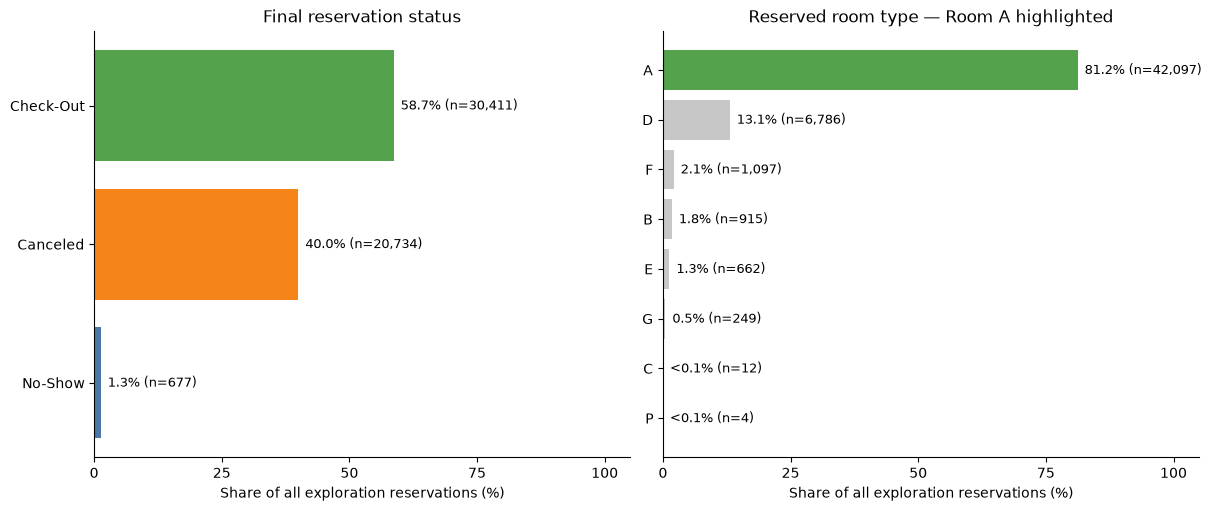

In [8]:
status_counts = train['ReservationStatus'].value_counts().reindex(['Check-Out', 'Canceled', 'No-Show'])
reserved_counts = train['ReservedRoomType'].fillna('Missing').value_counts()
status_rates = status_counts / len(train) * 100
reserved_rates = reserved_counts / len(train) * 100
assert status_counts.sum() == reserved_counts.sum() == len(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
axes[0].barh(status_rates.index, status_rates, color=[GREEN, AMBER, BLUE])
room_colors = [GREEN if room == 'A' else '#c7c7c7' for room in reserved_rates.index]
axes[1].barh(reserved_rates.index, reserved_rates, color=room_colors)

for ax, counts, rates in zip(axes, [status_counts, reserved_counts], [status_rates, reserved_rates]):
    percentages = ['<0.1%' if 0 < rate < 0.1 else f'{rate:.1f}%' for rate in rates]
    labels = [f'{percent} (n={count:,})' for count, percent in zip(counts, percentages)]
    ax.bar_label(ax.containers[0], labels=labels, padding=5, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 105)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xlabel('Share of all exploration reservations (%)')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_title('Final reservation status')
axes[1].set_title('Reserved room type — Room A highlighted')
show_figure(fig, 'status_and_room_share')

Completed stays account for **58.7%**, cancellations **40.0%**, and no-shows **1.3%**. `IsCanceled=1` combines the last two outcomes.

Room A represents **81.2% (42,097 reservations)**, making it a useful group to examine separately. This is its share of bookings, not its share of physical rooms.

**Unusual rates**

I inspect the highest ADR values to see how much extreme rates could affect a typical price.

In [9]:
display(train.nlargest(5, 'ADR')[['arrival_date', 'ADR', 'total_nights', 'ReservationStatus', 'ReservedRoomType']])

,arrival_date,ADR,total_nights,ReservationStatus,ReservedRoomType
8455,2016-03-25,5400.00,1,Canceled,A
63852,2016-12-31,451.50,2,Check-Out,E
63729,2016-12-30,375.50,2,Check-Out,D
53786,2016-07-25,365.00,3,Check-Out,A
63713,2016-12-29,349.63,3,Check-Out,F


## 2. Hotel-wide booking patterns

This section uses all room types in 2015–2016. Completed-stay analyses use the stated subsets.

**Lead time**

I compare all reservations, completed stays, and canceled or no-show bookings. Each curve uses its own group's records as the denominator.

In [10]:
groups = {
    'All reservations': train,
    'Completed stays': train[train['ReservationStatus'] == 'Check-Out'],
    'Canceled / no-show': train[train['IsCanceled'] == 1],
}

# Compute the same statistics for each group, then put the rows together.
rows = []
for name, bookings in groups.items():
    lead_days = bookings['LeadTime']
    rows.append({
        'group': name,
        'records': len(bookings),
        'median_days': lead_days.median(),
        'p90_days': lead_days.quantile(0.90),
        'p95_days': lead_days.quantile(0.95),
        'share_le_30': (lead_days <= 30).mean(),
        'share_le_90': (lead_days <= 90).mean(),
        'share_le_300': (lead_days <= 300).mean(),
    })
lead_summary = pd.DataFrame(rows).set_index('group')
display(lead_summary)

,records,median_days,p90_days,p95_days,share_le_30,share_le_90,share_le_300
group,,,,,,,
All reservations,51822,69.0,286.0,332.0,0.311875,0.579464,0.916213
Completed stays,30411,44.0,192.0,257.0,0.416658,0.700240,0.975930
Canceled / no-show,21411,115.0,335.0,384.0,0.163047,0.407921,0.831395


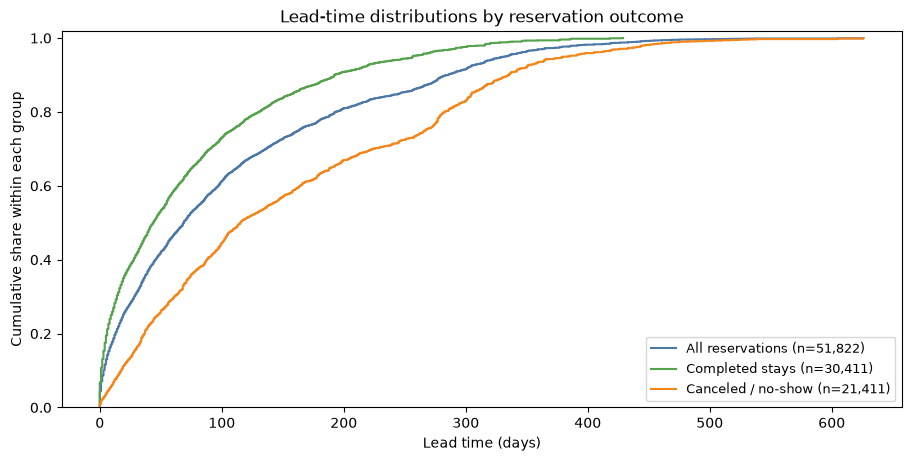

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
for (name, g), color in zip(groups.items(), [BLUE, GREEN, AMBER]):
    x = np.sort(g['LeadTime'].to_numpy())
    cumulative_share = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, cumulative_share, where='post', label=f'{name} (n={len(x):,})', color=color)
ax.set(xlabel='Lead time (days)', ylabel='Cumulative share within each group', ylim=(0, 1.02),
       title='Lead-time distributions by reservation outcome')
ax.legend(loc='lower right', fontsize=9)
show_figure(fig, 'lead_time')

The median lead time is **69 days**. Only **31.2%** of reservations were made within 30 days of arrival, so looking at the last month would miss many bookings.

A 90th percentile of 301 days means about 90% of records have lead times at or below 301 days. These figures describe recorded reservations, not everyone who considered booking.

**Calendar patterns**

The data begins in July 2015. I show the monthly sequence, then use 2016 alone to compare a complete year. Counts per day measure reservations, not occupancy.

In [12]:
completed = train['ReservationStatus'] == 'Check-Out'
positive_nights = train['total_nights'] > 0
positive_rate = train['ADR'] > 0
positive_completed = train.loc[completed & positive_nights & positive_rate].copy()
monthly = train.groupby(train['arrival_date'].dt.to_period('M')).agg(
    reservations=('IsCanceled', 'size'), canceled_or_no_show=('IsCanceled', 'sum'))
monthly['completed'] = monthly.reservations - monthly.canceled_or_no_show
monthly['completed_positive_adr_median'] = positive_completed.groupby(positive_completed['arrival_date'].dt.to_period('M')).ADR.median()
display(monthly)
annual = monthly.loc['2016-01':'2016-12'].copy()
annual['calendar_days'] = annual.index.days_in_month
annual['reservations_per_day'] = annual.reservations / annual.calendar_days
annual['completed_per_day'] = annual.completed / annual.calendar_days
assert len(annual) == 12

,reservations,canceled_or_no_show,completed,completed_positive_adr_median
arrival_date,,,,
2015-07,1398,939,459,80.000
2015-08,2480,1232,1248,81.000
2015-09,3529,1543,1986,100.565
2015-10,3386,1321,2065,90.000
2015-11,1235,301,934,70.000
2015-12,1654,668,986,75.000
2016-01,1364,438,926,77.600
2016-02,2371,930,1441,81.000
2016-03,3046,1108,1938,85.000


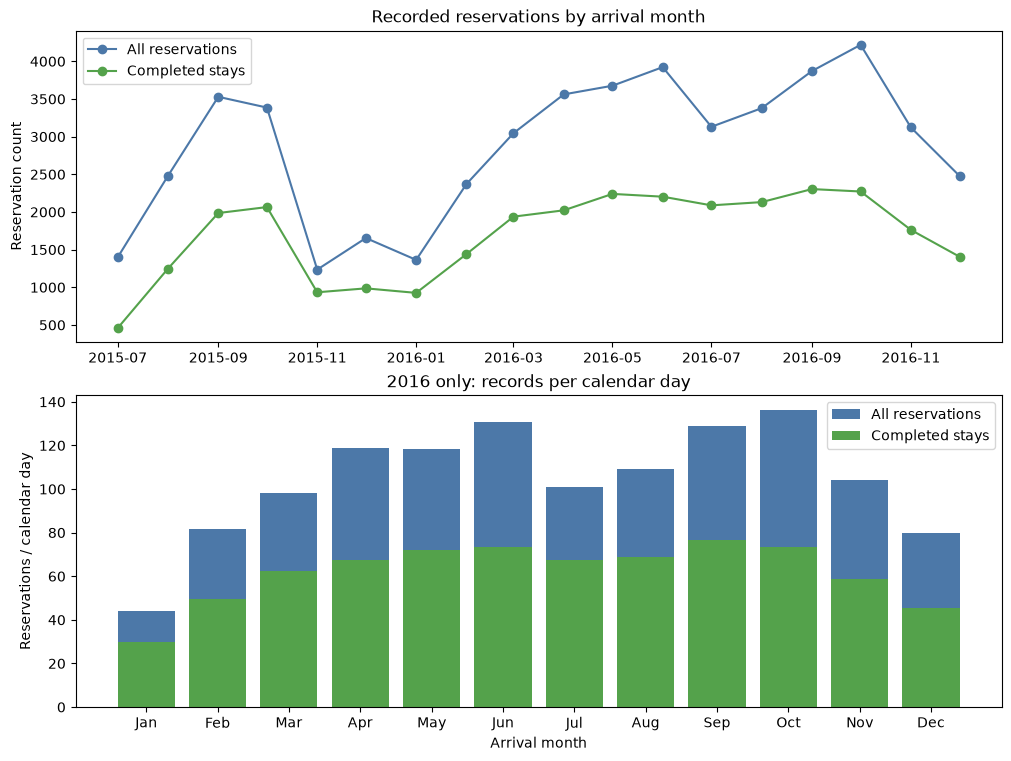

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), layout='constrained')
x = monthly.index.to_timestamp()
axes[0].plot(x, monthly.reservations, marker='o', color=BLUE, label='All reservations')
axes[0].plot(x, monthly.completed, marker='o', color=GREEN, label='Completed stays')
axes[0].set(title='Recorded reservations by arrival month', ylabel='Reservation count')
axes[0].legend()
axes[1].bar(range(1, 13), annual.reservations_per_day, color=BLUE, label='All reservations')
axes[1].bar(range(1, 13), annual.completed_per_day, color=GREEN, label='Completed stays')
axes[1].set(title='2016 only: records per calendar day', ylabel='Reservations / calendar day',
            xticks=range(1, 13), xticklabels=list(calendar.month_abbr)[1:], xlabel='Arrival month')
axes[1].legend()
show_figure(fig, 'calendar_patterns')

Several spring and autumn months have more reservations than January. Completed stays follow a different pattern because cancellations also vary. One full year gives limited evidence for a stable seasonal pattern.

**Cancellations and stay length**

I compare cancellation or no-show rates across lead-time groups. For stay length, I use completed reservations with positive nights.

In [14]:
status_summary = train['ReservationStatus'].value_counts().rename('records').to_frame()
status_summary['share'] = status_summary.records / len(train)
display(status_summary)
train['lead_bucket'] = pd.cut(train['LeadTime'], bins=[-1, 7, 30, 90, 180, 365, np.inf],
                            labels=['0–7', '8–30', '31–90', '91–180', '181–365', '366+'])
cancel_by_lead = train.groupby('lead_bucket', observed=False).agg(records=('IsCanceled', 'size'),
    canceled_or_no_show_rate=('IsCanceled', 'mean'))
display(cancel_by_lead)
stays = train.loc[train['ReservationStatus'].eq('Check-Out') & train['total_nights'].gt(0)]
stay_summary = stays['total_nights'].describe(percentiles=[.5, .9, .99])
display(stay_summary.to_frame('Completed stay length (nights)'))

,records,share
ReservationStatus,,
Check-Out,30411,0.586836
Canceled,20734,0.400100
No-Show,677,0.013064


,records,canceled_or_no_show_rate
lead_bucket,,
0–7,7906,0.129016
8–30,8256,0.299297
31–90,13867,0.378092
91–180,10308,0.467210
181–365,10060,0.658549
366+,1425,0.867368


,Completed stay length (nights)
count,30177.000000
mean,2.883023
std,1.743731
min,1.000000
50%,3.000000
90%,5.000000
99%,8.000000
max,57.000000


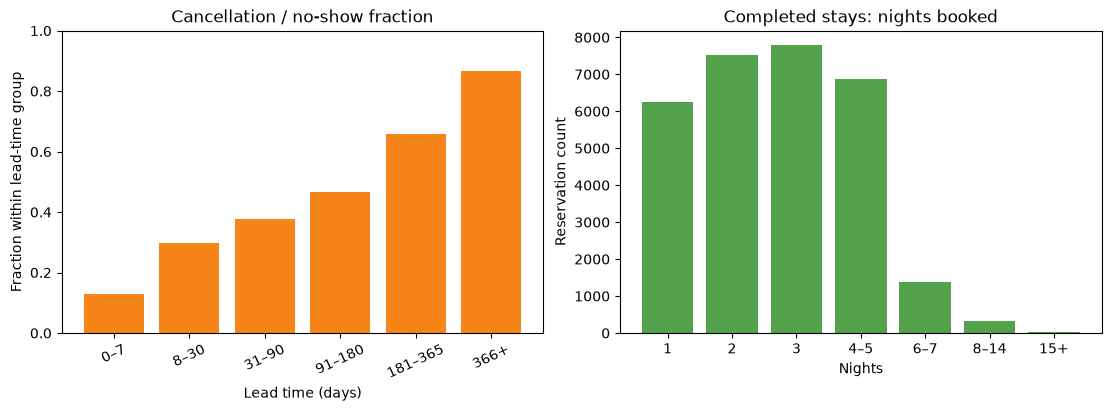

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].bar(cancel_by_lead.index.astype(str), cancel_by_lead.canceled_or_no_show_rate, color=AMBER)
axes[0].set(title='Cancellation / no-show fraction', xlabel='Lead time (days)', ylabel='Fraction within lead-time group', ylim=(0, 1))
axes[0].tick_params(axis='x', rotation=25)
stay_buckets = pd.cut(stays['total_nights'], [0, 1, 2, 3, 5, 7, 14, np.inf], labels=['1', '2', '3', '4–5', '6–7', '8–14', '15+'])
axes[1].bar(stay_buckets.value_counts(sort=False).index.astype(str), stay_buckets.value_counts(sort=False), color=GREEN)
axes[1].set(title='Completed stays: nights booked', xlabel='Nights', ylabel='Reservation count')
show_figure(fig, 'cancellations_and_stays')

Bookings made further ahead have higher cancellation or no-show rates in this sample. Each rate divides canceled or no-show bookings by all reservations in the same lead-time group. This is an association, not evidence that early booking causes cancellation.

Completed stays have a median length of **3 nights**, and only **20.7%** last one night. A one-night model would therefore simplify a typical stay.

**Customer mix**

I compare market segments to see which groups dominate the records. These counts alone cannot tell us how each group responds to price.

In [16]:
segment = train.groupby('MarketSegment', dropna=False).agg(records=('IsCanceled', 'size'),
    cancellation_flag_rate=('IsCanceled', 'mean'), median_lead_days=('LeadTime', 'median')).sort_values('records', ascending=False)
display(segment)

,records,cancellation_flag_rate,median_lead_days
MarketSegment,,,
Online TA,22771,0.348162,50.0
Offline TA/TO,13003,0.429516,105.0
Groups,9636,0.700498,215.0
Direct,3688,0.181941,12.5
Corporate,2202,0.183015,8.0
Complementary,393,0.109415,2.0
Aviation,127,0.228346,4.0
Undefined,2,1.000000,1.5


## 3. Room A

Room A has 42,097 reservations in the earlier period. I use all of them for lead time, and completed stays with positive nights and ADR for the price analysis.

**Typical rate**

I apply the filters one at a time so we can see which records define the price scale.

In [17]:
# Choose the most common reserved room type, then filter one step at a time.
room_counts = train['ReservedRoomType'].value_counts()
ROOM = room_counts.index[0]
room_records = train[train['ReservedRoomType'] == ROOM].copy()
completed_room = room_records[room_records['ReservationStatus'] == 'Check-Out']
positive_night_room = completed_room[completed_room['total_nights'] > 0]
calibration = positive_night_room[positive_night_room['ADR'] > 0].copy()

# Keep a short record of how many rows each filter removes.
steps = [
    ('Training reservations', train),
    (f'Reserved room {ROOM}', room_records),
    ('Completed stays', completed_room),
    ('Positive stay length', positive_night_room),
    ('Positive recorded ADR', calibration),
]
rows = []
previous_count = len(train)
for label, bookings in steps:
    rows.append({'step': label, 'retained': len(bookings),
                 'removed_at_step': previous_count - len(bookings)})
    previous_count = len(bookings)
ledger = pd.DataFrame(rows)
display(ledger)
assert ledger['removed_at_step'].sum() + len(calibration) == len(train)

,step,retained,removed_at_step
0,Training reservations,51822,0
1,Reserved room A,42097,9725
2,Completed stays,23842,18255
3,Positive stay length,23650,192
4,Positive recorded ADR,23210,440


In [18]:
adr_quantiles = calibration['ADR'].quantile([0, .01, .1, .25, .5, .75, .9, .99, 1])
display(adr_quantiles.rename('Recorded ADR (source units)').to_frame())

,Recorded ADR (source units)
0.00,1.0000
0.01,46.6327
0.10,65.0000
0.25,75.0000
0.50,90.9500
0.75,110.4600
0.90,130.0000
0.99,175.4622
1.00,365.0000


The filters leave **23,210 completed stays**, with median ADR **90.95**. The median is less affected by extreme rates than the mean.

I retain extreme rates in the statistics. The histogram ends at the 99th percentile only to make the main distribution readable. Rates remain in the source units.

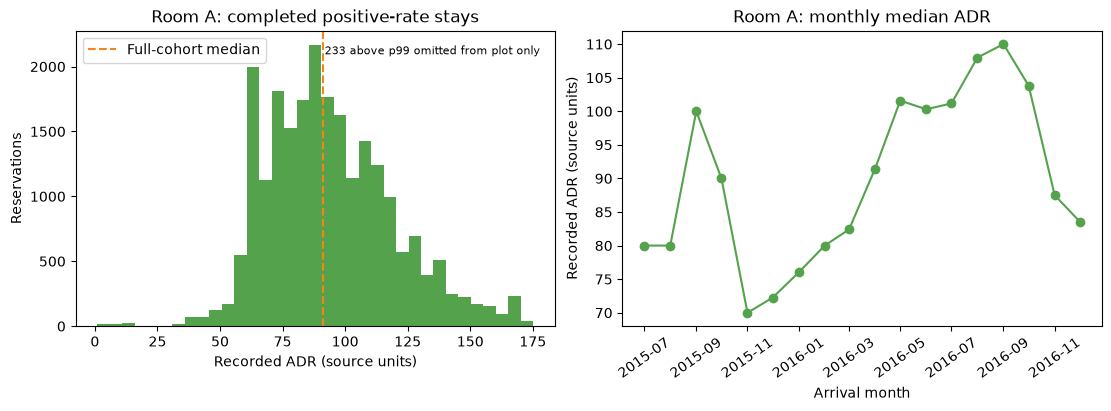

In [19]:
plot_limit = calibration['ADR'].quantile(.99)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
axes[0].hist(calibration.loc[calibration['ADR'].le(plot_limit), 'ADR'], bins=35, color=GREEN)
axes[0].axvline(calibration['ADR'].median(), color=AMBER, linestyle='--', label='Full-cohort median')
axes[0].set(title=f'Room {ROOM}: completed positive-rate stays', xlabel='Recorded ADR (source units)', ylabel='Reservations')
axes[0].legend()
axes[0].text(.97, .92, f'{calibration['ADR'].gt(plot_limit).sum()} above p99 omitted from plot only',
             transform=axes[0].transAxes, ha='right', fontsize=8)
room_monthly_adr = calibration.groupby(calibration['arrival_date'].dt.to_period('M')).ADR.median()
axes[1].plot(room_monthly_adr.index.to_timestamp(), room_monthly_adr, marker='o', color=GREEN)
axes[1].set(title=f'Room {ROOM}: monthly median ADR', xlabel='Arrival month', ylabel='Recorded ADR (source units)')
axes[1].tick_params(axis='x', rotation=35)
show_figure(fig, 'adr_patterns')

Rounding 90.95 to the nearest multiple of five gives **90**, a convenient reference price. It is not an estimated optimal price. Monthly medians vary, so one number summarizes only part of the pattern.

**Booking window and duplicate sensitivity**

I choose a window covering most room-A lead times: take the 90th percentile, include arrival day, then round up to a multiple of 30.

I also repeat the calculation after removing identical source rows. Room-level statistics refer to A; total rows and cancellation rates describe the whole hotel.

In [20]:
p90_lead_days = room_records['LeadTime'].quantile(0.90)
days_including_arrival = p90_lead_days + 1
HORIZON = int(30 * math.ceil(days_including_arrival / 30))

def cohort_statistics(g):
    room = g.loc[g['ReservedRoomType'].eq(ROOM)]
    completed = room.loc[room['ReservationStatus'].eq('Check-Out') & room['total_nights'].gt(0) & room['ADR'].gt(0)]
    return {'all_records': len(g), 'room_records': len(room), 'room_completed_positive_records': len(completed),
            'cancellation_flag_rate': g['IsCanceled'].mean(), 'room_median_ADR': completed['ADR'].median(),
            'room_p90_lead_days': room['LeadTime'].quantile(.9),
            'room_share_within_proposed_horizon': room['LeadTime'].lt(HORIZON).mean()}
deduped = train.drop_duplicates(subset=source_cols)
sensitivity = pd.DataFrame({'Keep all source records (primary)': cohort_statistics(train),
                           'Drop identical source-field rows (sensitivity)': cohort_statistics(deduped)}).T
display(sensitivity)
print(f'Proposed horizon: {HORIZON} daily decisions (lead days 0–{HORIZON-1}); room {ROOM} recorded booking coverage: {room_records['LeadTime'].lt(HORIZON).mean():.1%}')
print(f'Coverage for completed room-{ROOM} reservations: {room_records.loc[room_records['ReservationStatus'].eq("Check-Out"), "LeadTime"].lt(HORIZON).mean():.1%}')
print(f'Room records outside the proposed horizon: {room_records['LeadTime'].ge(HORIZON).sum():,}; these records remain in the audit.')

,all_records,room_records,room_completed_positive_records,cancellation_flag_rate,room_median_ADR,room_p90_lead_days,room_share_within_proposed_horizon
Keep all source records (primary),51822.0,42097.0,23210.0,0.413164,90.95,301.0,0.936385
Drop identical source-field rows (sensitivity),33309.0,24305.0,17384.0,0.276502,92.00,183.0,0.989961


Proposed horizon: 330 daily decisions (lead days 0–329); room A recorded booking coverage: 93.6%
Coverage for completed room-A reservations: 98.5%
Room records outside the proposed horizon: 2,678; these records remain in the audit.


Room A's 90th-percentile lead time is **301 days**, including reservations later canceled. Lead days 0–301 require 302 daily decisions. Rounding up gives:

`ceil((301 + 1) / 30) × 30 = 330 days`

This covers lead days 0–329, or **93.6%** of room-A reservations. The 90% target and rounding rule are design choices.

Removing identical rows reduces room-A p90 from **301 to 183 days** and the hotel-wide cancellation/no-show rate from **41.3% to 27.7%**. I keep the rows because separate anonymized reservations may look identical, but this sensitivity matters when choosing the window.

## 4. Parameters for a small simulator

I use the booking patterns to choose a room type, reference price, and selling window. Capacity and customer response require additional assumptions. The accepted settings are saved separately in `configs/hotel_v1.json`.

In [21]:
# Round to a multiple of 5 so the demo prices are easy to read.
def round_to_five(value):
    return int(5 * np.floor(value / 5 + 0.5))

REFERENCE = round_to_five(calibration['ADR'].median())
MULTIPLIERS = [0.6, 0.8, 1.0, 1.2, 1.4]
MENU = []
for multiplier in MULTIPLIERS:
    MENU.append(round_to_five(REFERENCE * multiplier))

CAPACITY = 10
EXPECTED_REFERENCE_SALES = 12
P_REF = EXPECTED_REFERENCE_SALES / HORIZON
BETA = 4

simulator_parameters = {
    'room_type': ROOM,
    'horizon': HORIZON,
    'capacity': CAPACITY,
    'reference_price': REFERENCE,
    'prices': MENU,
    'reference_sale_probability': P_REF,
    'price_response_slope': BETA,
    'stay_nights': 1,
    'cancellations': False,
    'seasonality': False,
}

In [22]:
display(Markdown(f"""
- **Room type — {ROOM}:** the most common reserved code; used as the basis for one abstract room type.
- **Reference price — {REFERENCE}:** rounded from the completed, positive-night, positive-ADR cohort's median.
- **Booking horizon — {HORIZON} daily decisions:** lead days 0–{HORIZON - 1}; a coverage-based candidate that remains sensitive to identical records.
- **Price actions — {MENU}:** chosen multipliers around the reference, not estimated optimal prices.
- **Capacity — {CAPACITY} rooms:** a small assumed inventory, not the hotel's measured capacity.
- **Sale response — reference probability {P_REF:.2%} per day, slope {BETA}:** an assumed {EXPECTED_REFERENCE_SALES} expected sales over the full horizon at the reference price, before capacity limits. This is a combined sale probability, not an estimated shopper-arrival rate.
- **Initial scope — one stay night, no cancellations, no seasonality:** keep the first decision problem small; revisit these omissions after the basic workflow is clear.
"""))


- **Room type — A:** the most common reserved code; used as the basis for one abstract room type.
- **Reference price — 90:** rounded from the completed, positive-night, positive-ADR cohort's median.
- **Booking horizon — 330 daily decisions:** lead days 0–329; a coverage-based candidate that remains sensitive to identical records.
- **Price actions — [55, 70, 90, 110, 125]:** chosen multipliers around the reference, not estimated optimal prices.
- **Capacity — 10 rooms:** a small assumed inventory, not the hotel's measured capacity.
- **Sale response — reference probability 3.64% per day, slope 4:** an assumed 12 expected sales over the full horizon at the reference price, before capacity limits. This is a combined sale probability, not an estimated shopper-arrival rate.
- **Initial scope — one stay night, no cancellations, no seasonality:** keep the first decision problem small; revisit these omissions after the basic workflow is clear.


**Price menu and sale probability**

Multipliers `[0.6, 0.8, 1.0, 1.2, 1.4]` around 90, rounded to the nearest five, give prices **55, 70, 90, 110, and 125**.

I assume 10 rooms and 12 expected sales at price 90 before the inventory limit. Over 330 days, the reference sale probability is `12 / 330 ≈ 3.64%` per day.

`p(price) = sigmoid(logit(p_ref) - beta × (price / reference - 1))`

At price 90, the probability equals `p_ref`. A larger `beta` makes demand more sensitive to price. I use 4 and plot 2 and 6 for comparison. These curves are assumptions, not estimates from the booking data.

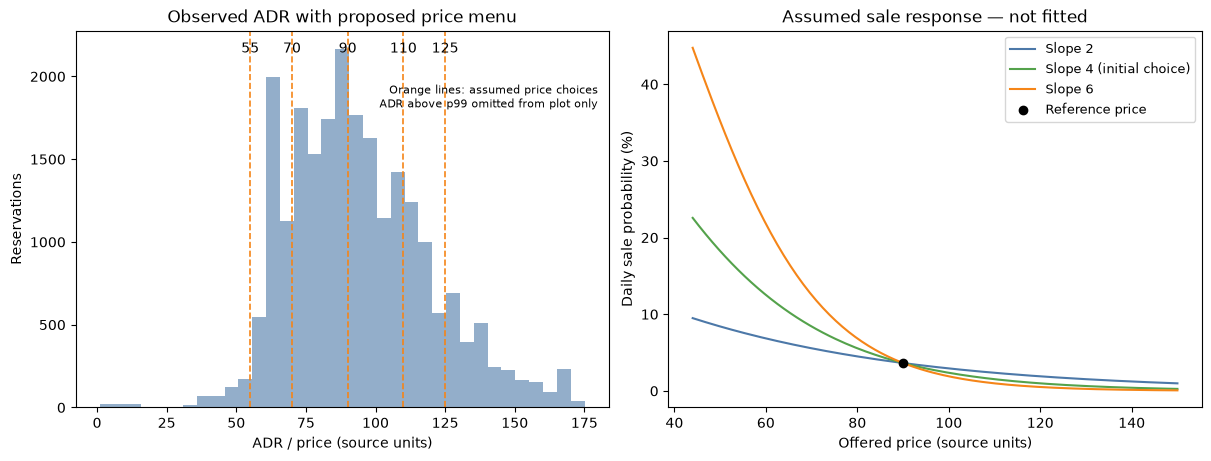

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
axes[0].hist(calibration.loc[calibration['ADR'] <= plot_limit, 'ADR'], bins=35, color=BLUE, alpha=0.6)
for price in MENU:
    axes[0].axvline(price, color=AMBER, linestyle='--', linewidth=1.2)
    axes[0].text(price, 0.97, str(price), transform=axes[0].get_xaxis_transform(), ha='center', va='top')
axes[0].set(title='Observed ADR with proposed price menu', xlabel='ADR / price (source units)', ylabel='Reservations')
axes[0].text(0.98, 0.86, 'Orange lines: assumed price choices\nADR above p99 omitted from plot only',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8)

price_grid = np.linspace(min(MENU) * 0.8, max(MENU) * 1.2, 150)
for beta, color in zip([2, BETA, 6], [BLUE, GREEN, AMBER]):
    logit = np.log(P_REF / (1 - P_REF)) - beta * (price_grid / REFERENCE - 1)
    probability = 1 / (1 + np.exp(-logit))
    label = f'Slope {beta}' + (' (initial choice)' if beta == BETA else '')
    axes[1].plot(price_grid, probability * 100, color=color, label=label)
axes[1].scatter([REFERENCE], [P_REF * 100], color='black', zorder=3, label='Reference price')
axes[1].set(title='Assumed sale response — not fitted', xlabel='Offered price (source units)', ylabel='Daily sale probability (%)')
axes[1].legend(fontsize=9)
show_figure(fig, 'simulator_parameters')

Lower prices make a sale more likely in this assumed model; higher prices earn more per sale but risk leaving rooms empty. The bookings support the price scale and window, but do not identify this price response or the hotel's available inventory.

The decision uses time and rooms remaining, chooses one price, and receives actual sales revenue. Later outcomes such as final reservation status are not pricing-time inputs.

The [environment specification](../../versions/Sep_25_v1/docs/environment_spec.md) records the assumptions.

**Save the findings**

I save the summary and audit files so the figures and parameter calculations can be checked again.

In [24]:
stats = {
    'training_rows': len(train), 'reserved_rows': len(holdout_index), 'room_code': ROOM,
    'room_share': float(room_counts.iloc[0]/len(train)), 'price_cohort_rows': len(calibration),
    'all_median_lead_days': float(train['LeadTime'].median()), 'all_share_le_30': float(train['LeadTime'].le(30).mean()),
    'room_p90_lead_days': float(room_records['LeadTime'].quantile(.9)), 'horizon_days': HORIZON,
    'room_horizon_coverage': float(room_records['LeadTime'].lt(HORIZON).mean()),
    'room_median_ADR': float(calibration['ADR'].median()), 'reference_price': REFERENCE, 'price_menu': MENU,
    'canceled_fraction': float(train['ReservationStatus'].eq('Canceled').mean()),
    'no_show_fraction': float(train['ReservationStatus'].eq('No-Show').mean()),
    'cancellation_flag_fraction': float(train['IsCanceled'].mean()),
    'completed_median_nights': float(stays['total_nights'].median()),
    'completed_single_night_fraction': float(stays['total_nights'].eq(1).mean()),
    'normalized_duplicate_rows': int(train[source_cols].duplicated().sum()),
    'dedup_room_p90_lead_days': float(sensitivity.iloc[1].room_p90_lead_days),
    'dedup_cancellation_flag_fraction': float(sensitivity.iloc[1].cancellation_flag_rate),
}

In [25]:
versions = {
    package: importlib.metadata.version(package)
    for package in ['pandas', 'numpy', 'matplotlib', 'nbformat', 'nbclient', 'nbconvert', 'ipykernel']
}
summary = {'source_sha256': manifest['sha256'], 'cutoff': str(CUTOFF.date()),
           'versions': versions, 'findings': stats,
           'assumptions': {'capacity': 10, 'reference_sale_probability': 12/HORIZON,
                           'elasticity_scenarios': [2, 4, 6], 'price_multipliers': MULTIPLIERS}}
(OUT / 'proposed_simulator_parameters.json').write_text(json.dumps(simulator_parameters, indent=2) + '\n')
(OUT / 'summary.json').write_text(json.dumps(summary, indent=2)+'\n')
for name, table in [('audit', audit.to_frame()), ('missing', missing.to_frame('count')),
                    ('filter_ledger', ledger), ('lead_summary', lead_summary), ('monthly', monthly),
                    ('cancellation_by_lead', cancel_by_lead), ('segments', segment), ('duplicate_sensitivity', sensitivity)]:
    table.to_csv(OUT / f'{name}.csv', index=True)


print('Saved summary.json and audit tables to outputs/analysis.')

Saved summary.json and audit tables to outputs/analysis.
